In [1]:
import sys
sys.path.append("/Users/chris/Documents/higs-vision")
import torch
import numpy as np
import json
import matplotlib.pyplot as plt

from src.data import load_config, load_processed
from src.models import HiggsDNN
from src.explain import load_shap_results
from src.faithfulness import masking_proxy, random_masking_proxy, compute_abc, save_faithfulness_results
from src.physics_alignment import compute_alignment, find_disagreements, FEATURE_NAMES

config = load_config("/Users/chris/Documents/higs-vision/config.yaml")
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed(config)

with open("/Users/chris/Documents/higs-vision/results/optuna/best_params.json") as f:
    best = json.load(f)

# Load model
width = best["hidden_width"]
model = HiggsDNN(
    input_dim=28,
    hidden_dims=[width, width // 2, width // 4, width // 8],
    activation=best["activation"],
    dropout_rate=best["dropout"],
    use_batch_norm=best["batch_norm"]
)
model.load_state_dict(torch.load("/Users/chris/Documents/higs-vision/notebooks/models/dnn/final_optuna/model.pt"))
model.eval()

# Load SHAP results
shap_values, importance, ranking = load_shap_results("/Users/chris/Documents/higs-vision/results/shap/")

print("Setup complete")
print(f"SHAP ranking: {ranking[:5]}...")

Loaded processed data from /Users/chris/Documents/higs-vision/data/processed/
  Train: (700000, 28), Val: (150000, 28), Test: (150000, 28)
Setup complete
SHAP ranking: ['m_wwbb', 'm_wbb', 'm_bb', 'jet1_pT', 'lepton_pT']...


In [2]:
print("=" * 60)
print("FAITHFULNESS: SHAP-ORDERED MASKING PROXY")
print("=" * 60)

shap_proxy = masking_proxy(model, X_test, y_test, ranking, FEATURE_NAMES)

FAITHFULNESS: SHAP-ORDERED MASKING PROXY
  k= 1: ROC-AUC = 0.8015 (removed: m_wwbb)
  k= 2: ROC-AUC = 0.7817 (removed: m_wbb)
  k= 3: ROC-AUC = 0.7023 (removed: m_bb)
  k= 4: ROC-AUC = 0.6748 (removed: jet1_pT)
  k= 5: ROC-AUC = 0.6310 (removed: lepton_pT)
  k=10: ROC-AUC = 0.5659 (removed: jet3_pT)
  k=15: ROC-AUC = 0.5111 (removed: jet1_eta)
  k=20: ROC-AUC = 0.4861 (removed: jet2_eta)
  k=25: ROC-AUC = 0.5071 (removed: jet4_phi)


/Users/chris/Documents/higs-vision/.higs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  k=28: ROC-AUC = 0.5000 (removed: jet3_phi)


In [3]:
print("\n" + "=" * 60)
print("FAITHFULNESS: RANDOM-ORDERED MASKING PROXY")
print("=" * 60)

random_proxy = random_masking_proxy(model, X_test, y_test, FEATURE_NAMES, n_orderings=3, seed=100)


FAITHFULNESS: RANDOM-ORDERED MASKING PROXY

  Random ordering 1/3
  k= 1: ROC-AUC = 0.8403 (removed: jet2_pT)
  k= 2: ROC-AUC = 0.7776 (removed: m_wbb)
  k= 3: ROC-AUC = 0.7732 (removed: m_jj)
  k= 4: ROC-AUC = 0.7700 (removed: jet2_b-tag)
  k= 5: ROC-AUC = 0.7439 (removed: jet1_pT)
  k=10: ROC-AUC = 0.6270 (removed: jet3_pT)
  k=15: ROC-AUC = 0.5755 (removed: lepton_eta)
  k=20: ROC-AUC = 0.5685 (removed: lepton_phi)
  k=25: ROC-AUC = 0.5622 (removed: jet1_phi)


/Users/chris/Documents/higs-vision/.higs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  k=28: ROC-AUC = 0.5000 (removed: jet1_b-tag)

  Random ordering 2/3
  k= 1: ROC-AUC = 0.8468 (removed: jet3_pT)
  k= 2: ROC-AUC = 0.8240 (removed: m_jlv)
  k= 3: ROC-AUC = 0.8241 (removed: lepton_phi)
  k= 4: ROC-AUC = 0.8211 (removed: jet4_b-tag)
  k= 5: ROC-AUC = 0.7879 (removed: lepton_pT)
  k=10: ROC-AUC = 0.7144 (removed: jet1_pT)
  k=15: ROC-AUC = 0.5292 (removed: missing_energy_mag)
  k=20: ROC-AUC = 0.5017 (removed: jet2_phi)
  k=25: ROC-AUC = 0.4947 (removed: missing_energy_phi)


/Users/chris/Documents/higs-vision/.higs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  k=28: ROC-AUC = 0.5000 (removed: m_wbb)

  Random ordering 3/3
  k= 1: ROC-AUC = 0.8393 (removed: jet1_eta)
  k= 2: ROC-AUC = 0.8367 (removed: jet4_eta)
  k= 3: ROC-AUC = 0.8311 (removed: jet3_eta)
  k= 4: ROC-AUC = 0.8274 (removed: jet3_pT)
  k= 5: ROC-AUC = 0.8273 (removed: jet2_phi)
  k=10: ROC-AUC = 0.8124 (removed: jet4_phi)
  k=15: ROC-AUC = 0.7170 (removed: lepton_pT)
  k=20: ROC-AUC = 0.6400 (removed: m_jjj)
  k=25: ROC-AUC = 0.5039 (removed: jet2_eta)


/Users/chris/Documents/higs-vision/.higs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  k=28: ROC-AUC = 0.5000 (removed: jet4_pT)


In [4]:
abc = compute_abc(shap_proxy, random_proxy)

print("=" * 60)
print("FAITHFULNESS RESULTS")
print("=" * 60)
print(f"Area Between Curves (ABC): {abc:.4f}")

# Compare specific points
shap_aucs = [r["roc_auc"] for r in shap_proxy]
random_aucs = [r["roc_auc_mean"] for r in random_proxy]

print(f"\nAfter removing top 5 features:")
print(f"  SHAP-ordered AUC: {shap_aucs[4]:.4f} (drop from {shap_aucs[0]:.4f})")
print(f"  Random-ordered AUC: {random_aucs[4]:.4f} (drop from {random_aucs[0]:.4f})")
print(f"  Difference: {random_aucs[4] - shap_aucs[4]:.4f}")

print(f"\nAfter removing top 10 features:")
print(f"  SHAP-ordered AUC: {shap_aucs[9]:.4f}")
print(f"  Random-ordered AUC: {random_aucs[9]:.4f}")
print(f"  Difference: {random_aucs[9] - shap_aucs[9]:.4f}")

FAITHFULNESS RESULTS
Area Between Curves (ABC): 2.3778

After removing top 5 features:
  SHAP-ordered AUC: 0.6310 (drop from 0.8015)
  Random-ordered AUC: 0.7863 (drop from 0.8421)
  Difference: 0.1553

After removing top 10 features:
  SHAP-ordered AUC: 0.5659
  Random-ordered AUC: 0.7179
  Difference: 0.1520


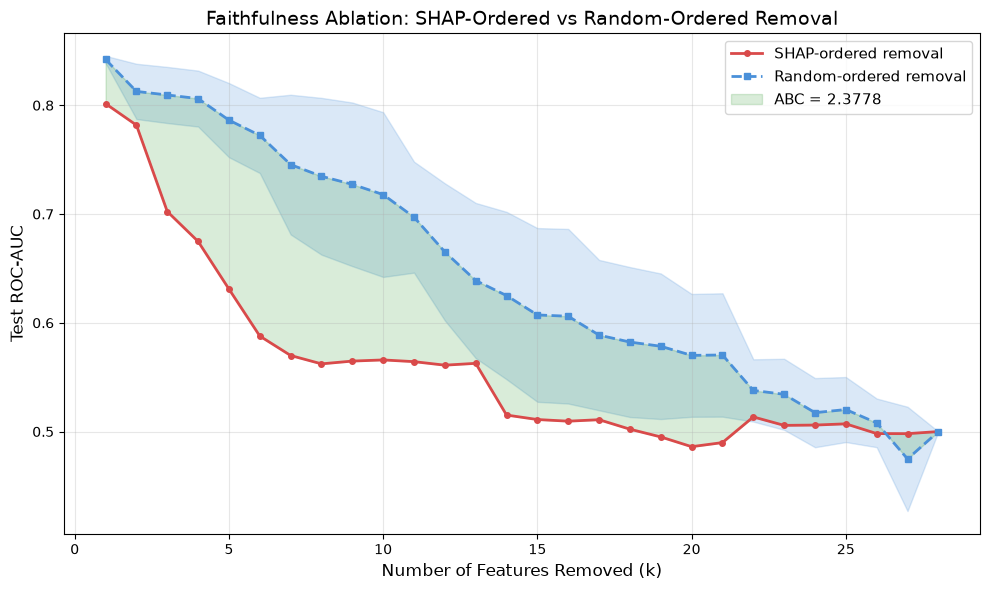

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

k_values = list(range(1, 29))

# SHAP-ordered curve
ax.plot(k_values, shap_aucs, "o-", color="#d94a4a", linewidth=2, markersize=4, label="SHAP-ordered removal")

# Random-ordered curve
ax.plot(k_values, random_aucs, "s--", color="#4a90d9", linewidth=2, markersize=4, label="Random-ordered removal")
ax.fill_between(
    k_values,
    [r["roc_auc_mean"] - r["roc_auc_std"] for r in random_proxy],
    [r["roc_auc_mean"] + r["roc_auc_std"] for r in random_proxy],
    alpha=0.2, color="#4a90d9"
)

# Fill between curves to show ABC
ax.fill_between(k_values, shap_aucs[:len(k_values)], random_aucs[:len(k_values)],
                alpha=0.15, color="green", label=f"ABC = {abc:.4f}")

ax.set_xlabel("Number of Features Removed (k)", fontsize=12)
ax.set_ylabel("Test ROC-AUC", fontsize=12)
ax.set_title("Faithfulness Ablation: SHAP-Ordered vs Random-Ordered Removal", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/faithfulness_ablation.png", dpi=150)
plt.show()

In [6]:
save_faithfulness_results(shap_proxy, random_proxy, abc,
                          "/Users/chris/Documents/higs-vision/results/metrics/faithfulness.json")

Faithfulness results saved to /Users/chris/Documents/higs-vision/results/metrics/faithfulness.json


In [7]:
print("=" * 60)
print("PHYSICS ALIGNMENT ANALYSIS")
print("=" * 60)

alignment = compute_alignment(importance, ranking)

print(f"\nSpearman rank correlation (ρ): {alignment['spearman_correlation']:.4f}")
print(f"Spearman p-value: {alignment['spearman_p_value']:.6f}")
print(f"\nTop-5 overlap: {alignment['top5_overlap_count']}/5")
print(f"  Physics top-5: {alignment['top5_physics']}")
print(f"  SHAP top-5:    {alignment['top5_shap']}")
print(f"  Overlap:       {alignment['top5_overlap_features']}")
print(f"\nTop-10 overlap: {alignment['top10_overlap_count']}/10")
print(f"  Overlap:       {alignment['top10_overlap_features']}")
print(f"\nFeature group allocation:")
print(f"  High-level (invariant masses): {alignment['high_level_shap_pct']:.1f}%")
print(f"  Low-level (raw kinematic):     {alignment['low_level_shap_pct']:.1f}%")

PHYSICS ALIGNMENT ANALYSIS

Spearman rank correlation (ρ): 0.8730
Spearman p-value: 0.000000

Top-5 overlap: 4/5
  Physics top-5: ['jet1_pT', 'm_bb', 'm_wbb', 'm_wwbb', 'missing_energy_mag']
  SHAP top-5:    ['jet1_pT', 'lepton_pT', 'm_bb', 'm_wbb', 'm_wwbb']
  Overlap:       ['jet1_pT', 'm_bb', 'm_wbb', 'm_wwbb']

Top-10 overlap: 7/10
  Overlap:       ['jet1_pT', 'jet2_pT', 'jet3_pT', 'm_bb', 'm_wbb', 'm_wwbb', 'missing_energy_mag']

Feature group allocation:
  High-level (invariant masses): 63.0%
  Low-level (raw kinematic):     37.0%


In [8]:
disagreements = find_disagreements(importance, ranking, top_n=10)

print("\n" + "=" * 60)
print("FEATURES WITH LARGEST RANK DISAGREEMENT")
print("=" * 60)
print(f"{'Feature':<20s} {'Physics Rank':>12s} {'SHAP Rank':>10s} {'Diff':>6s} {'Direction'}")
print("-" * 70)
for d in disagreements:
    print(f"{d['feature']:<20s} {d['physics_rank']:>12d} {d['shap_rank']:>10d} "
          f"{d['rank_difference']:>6d}   {d['direction']}")


FEATURES WITH LARGEST RANK DISAGREEMENT
Feature              Physics Rank  SHAP Rank   Diff Direction
----------------------------------------------------------------------
jet1_b-tag                      8         19     11   physics ranks higher
lepton_pT                      14          5      9   model ranks higher
jet2_b-tag                      9         17      8   physics ranks higher
jet3_b-tag                     10         16      6   physics ranks higher
m_jjj                          12          6      6   model ranks higher
jet4_pT                        17         12      5   model ranks higher
jet1_eta                       19         15      4   model ranks higher
m_jj                           13          9      4   model ranks higher
m_lv                           15         11      4   model ranks higher
missing_energy_mag              4          7      3   physics ranks higher


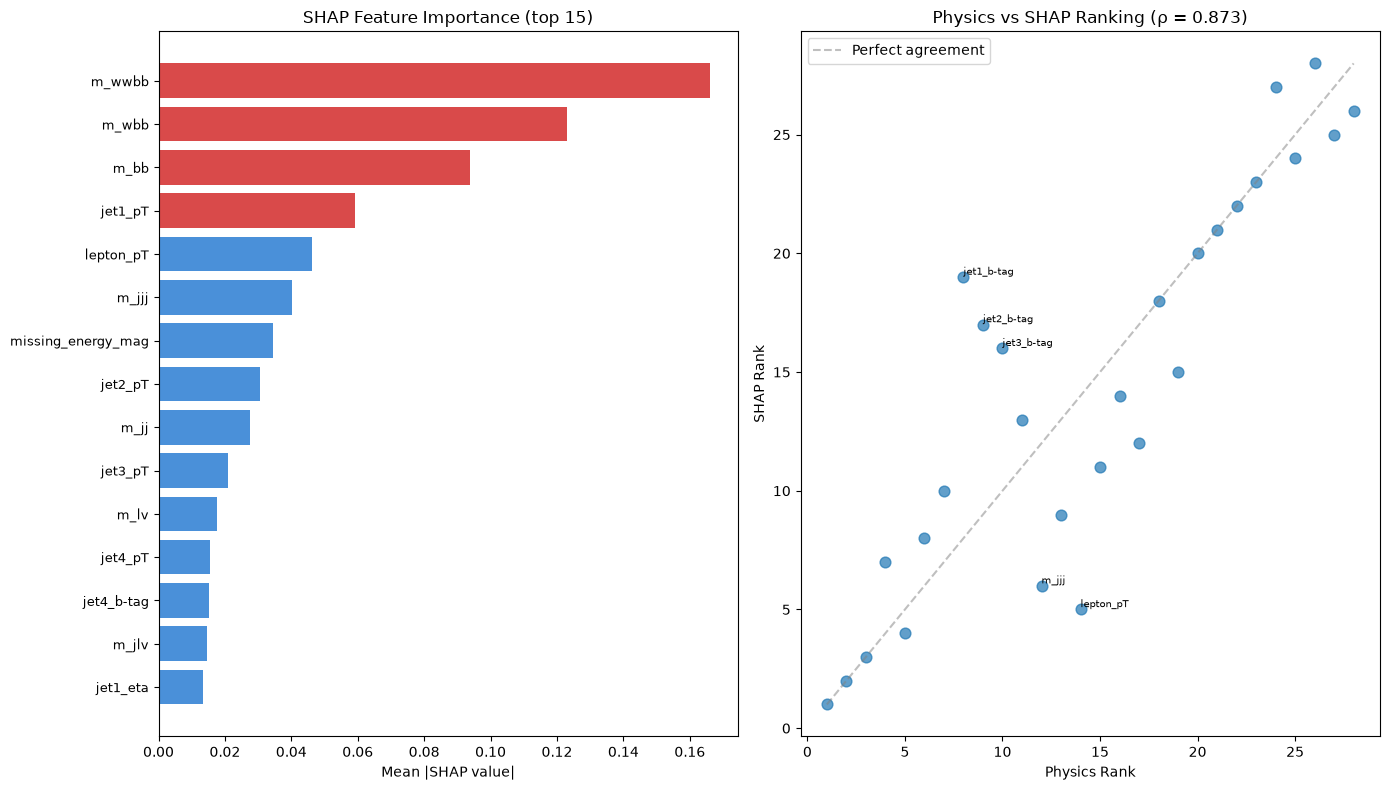

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# SHAP importance bar chart
top_n = 15
shap_features = ranking[:top_n]
shap_values_plot = [importance[f] for f in shap_features]
colors = ["#d94a4a" if f in alignment["top5_overlap_features"] else "#4a90d9" for f in shap_features]

axes[0].barh(range(top_n), shap_values_plot, color=colors)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(shap_features, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title("SHAP Feature Importance (top 15)")

# Physics vs SHAP rank scatter
from src.physics_alignment import PHYSICS_RANKING
physics_rank_map = {f: i + 1 for i, f in enumerate(PHYSICS_RANKING)}
shap_rank_map = {f: i + 1 for i, f in enumerate(ranking)}

all_features = FEATURE_NAMES
physics_ranks = [physics_rank_map[f] for f in all_features]
shap_ranks = [shap_rank_map[f] for f in all_features]

axes[1].scatter(physics_ranks, shap_ranks, s=60, alpha=0.7)
axes[1].plot([1, 28], [1, 28], "--", color="gray", alpha=0.5, label="Perfect agreement")

for i, feat in enumerate(all_features):
    if abs(physics_ranks[i] - shap_ranks[i]) > 5:
        axes[1].annotate(feat, (physics_ranks[i], shap_ranks[i]),
                         fontsize=7, ha="left", va="bottom")

axes[1].set_xlabel("Physics Rank")
axes[1].set_ylabel("SHAP Rank")
axes[1].set_title(f"Physics vs SHAP Ranking (ρ = {alignment['spearman_correlation']:.3f})")
axes[1].legend()

plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/physics_alignment.png", dpi=150)
plt.show()

In [10]:
with open("/Users/chris/Documents/higs-vision/results/metrics/physics_alignment.json", "w") as f:
    json.dump(alignment, f, indent=2)

with open("/Users/chris/Documents/higs-vision/results/metrics/disagreements.json", "w") as f:
    json.dump(disagreements, f, indent=2)

print("Alignment and disagreement results saved.")

Alignment and disagreement results saved.
